# 03 — Agent Evaluation

Step D of the work plan. This notebook **never spends money**. It analyses results produced by
`scripts/run_batch_triage.py`:

| Source | When it is used |
|---|---|
| `final_test_*.jsonl` | the live LLM evaluation on test claims, once it has run (`python scripts/run_batch_triage.py all`) |
| otherwise | a free **offline baseline**: the graph's rule-based path (no LLM) on real validation claims, using all 139 frauds plus 139 matched legitimate claims |

The offline baseline exercises the whole pipeline: ingest, validation, scoring, guardrails,
the human-review interrupt, metrics and plots. Its decisions equal the model-only threshold
policy by construction, so it is the reference the LLM agent is compared against.

**Live runs** happen on a laptop with a `.env` file (see `.env.example`):

```bash
python scripts/run_batch_triage.py estimate   # prints cost estimates, spends nothing
python scripts/run_batch_triage.py all        # pilot (asks) -> final test run (asks) -> report
```

In [1]:
SOURCE = "auto"          # "auto": latest final test results if present, else the offline baseline
OFFLINE_SPLIT = "validation"

In [2]:
import sys, json, glob
from pathlib import Path
NB = Path.cwd()
ROOT = next(p for p in [NB, *NB.parents] if (p / "config" / "settings.yaml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from evaluation import agent_eval as ae
from src.ml import eda
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "docs" / "report" / "figures"

In [3]:
finals = sorted((ROOT / "evaluation" / "results").glob("final_test_*.jsonl"))
if SOURCE == "auto" and finals:
    results_path, mode = finals[-1], "final (LLM agent, test set)"
    df = ae.load_results([results_path])
    legit_weight = None    # set below from the test split
else:
    from src.agent.runner import TriageRunner
    split = ae.load_split(OFFLINE_SPLIT)
    sample = ae.stratified_sample(split, legit_per_fraud=1)
    results_path = ROOT / "evaluation" / "results" / f"offline_{OFFLINE_SPLIT}_notebook.jsonl"
    results_path.unlink(missing_ok=True)
    print(f"offline baseline: {len(sample)} {OFFLINE_SPLIT} claims ({int(sample.FraudFound_P.sum())} frauds), no LLM")
    ae.run_batch(sample, TriageRunner(llm=None), OFFLINE_SPLIT, results_path, progress=lambda m: None)
    df = ae.load_results([results_path])
    mode = "offline baseline (rule-based, no LLM)"
    legit_weight = sample.attrs["legit_weight"]
if legit_weight is None:   # final runs: re-weight with the test split's legit/fraud ratio
    test = ae.load_split("test"); legit_weight = (len(test) - test.FraudFound_P.sum()) / test.FraudFound_P.sum()
summary = ae.summarize(df, legit_weight=legit_weight)
print(mode, "|", results_path.name, "|", len(df), "runs")

offline baseline: 278 validation claims (139 frauds), no LLM


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


offline baseline (rule-based, no LLM) | offline_validation_notebook.jsonl | 278 runs


## 1. Decision quality: agent vs model-only threshold policy

In [4]:
dq = summary["decision_quality"]
display(dq.round(3))
display(summary["agreement"])

,policy,metric,k,n,rate,lo,hi
0,agent,fraud -> FLAG (recall),93,139,0.669,0.587,0.742
1,agent,legit -> APPROVE,115,139,0.827,0.756,0.881
2,agent,legit -> FLAG (false-flag rate),24,139,0.173,0.119,0.244
3,agent,REQUEST_MORE_INFO (all claims),5,278,0.018,0.008,0.041
4,agent,FLAG precision (sample),93,117,0.795,NaN,NaN
5,agent,FLAG precision (re-weighted to true prevalence),93,117,0.199,NaN,NaN
6,model-only threshold policy,fraud -> FLAG (recall),93,139,0.669,0.587,0.742
7,model-only threshold policy,legit -> APPROVE,115,139,0.827,0.756,0.881
8,model-only threshold policy,legit -> FLAG (false-flag rate),24,139,0.173,0.119,0.244
9,model-only threshold policy,REQUEST_MORE_INFO (all claims),5,278,0.018,0.008,0.041


decision,APPROVE,FLAG_FOR_INVESTIGATION,REQUEST_MORE_INFO,All
model_only_decision,,,,
APPROVE,156,0,0,156
FLAG_FOR_INVESTIGATION,0,117,0,117
REQUEST_MORE_INFO,0,0,5,5
All,156,117,5,278


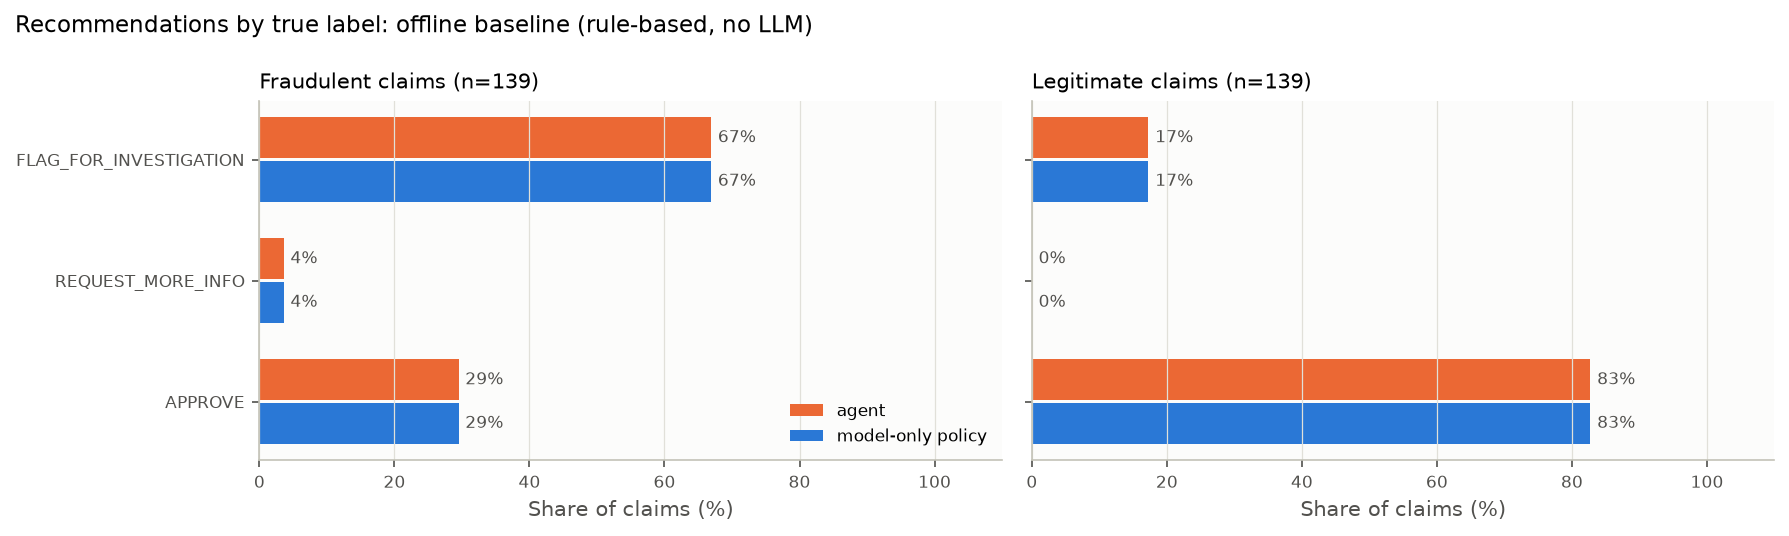

In [5]:
d = df[df.run_index == 0]
order = ["APPROVE", "REQUEST_MORE_INFO", "FLAG_FOR_INVESTIGATION"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (label, name) in zip(axes, [(1, "Fraudulent claims"), (0, "Legitimate claims")]):
    sub = d[d.label == label]
    agent = sub.decision.value_counts(normalize=True).reindex(order).fillna(0)
    model = sub.model_only_decision.value_counts(normalize=True).reindex(order).fillna(0)
    y = np.arange(len(order))
    ax.barh(y + 0.18, 100 * agent.values, height=0.34, color=eda.ORIGIN_COLORS["synthetic"], label="agent")
    ax.barh(y - 0.18, 100 * model.values, height=0.34, color=eda.ORIGIN_COLORS["real_train"], label="model-only policy")
    for yy, v in zip(y + 0.18, agent.values): ax.text(100 * v + 1, yy, f"{100*v:.0f}%", va="center", fontsize=8, color=eda.INK_2)
    for yy, v in zip(y - 0.18, model.values): ax.text(100 * v + 1, yy, f"{100*v:.0f}%", va="center", fontsize=8, color=eda.INK_2)
    ax.set_yticks(y, order); ax.invert_yaxis(); ax.set_xlim(0, 110)
    ax.set_xlabel("Share of claims (%)"); ax.set_title(f"{name} (n={len(sub)})", loc="left", fontsize=10)
    ax.grid(axis="x", color=eda.GRID, lw=0.6); eda.style_axes(ax)
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle(f"Recommendations by true label: {mode}", x=0.01, ha="left", fontsize=11)
fig.tight_layout(); eda.save(fig, FIG / "03_decisions_by_label.png"); display(Image(FIG / "03_decisions_by_label.png"))

## 2. Process: tool use, steps, guardrails, latency and cost

In [6]:
p = summary["process"]
display(pd.DataFrame([{"metric": k, "value": v} for k, v in p.items()]))
print("consistency:", summary["consistency"])

,metric,value
0,claims,278
1,errors,0
2,tool_use_rate,"{'check_policy_rules': 0.0, 'find_similar_claims': 0.0}"
3,mean_tool_calls,0.0
4,mean_agent_steps,0.0
5,max_steps_hits,0
6,fallback_rate,1.0
7,llm_failure_claims,0
8,guardrail_interventions,{'fallback': 278}
9,claims_with_grounding_removals,0


consistency: {'claims': 0}


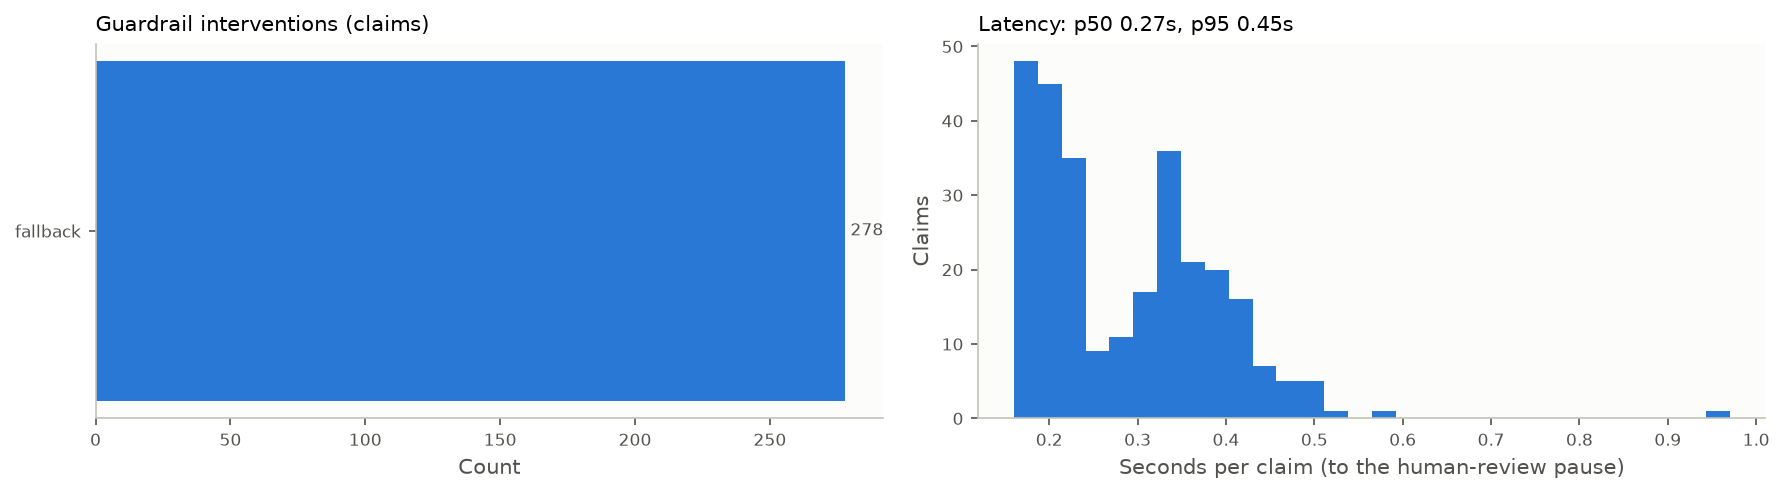

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
iv = pd.Series(p["guardrail_interventions"]).sort_values() if p["guardrail_interventions"] else pd.Series(dtype=float)
if len(iv):
    axes[0].barh(iv.index, iv.values, color=eda.ORIGIN_COLORS["real_train"], height=0.5)
    for i, v in enumerate(iv.values): axes[0].text(v, i, f" {v}", va="center", fontsize=8, color=eda.INK_2)
axes[0].set_title("Guardrail interventions (claims)", loc="left", fontsize=10); axes[0].set_xlabel("Count"); eda.style_axes(axes[0])
axes[1].hist(d.latency_s, bins=30, color=eda.ORIGIN_COLORS["real_train"])
axes[1].set_xlabel("Seconds per claim (to the human-review pause)"); axes[1].set_ylabel("Claims")
axes[1].set_title(f"Latency: p50 {p['latency_p50_s']:.2f}s, p95 {p['latency_p95_s']:.2f}s", loc="left", fontsize=10)
eda.style_axes(axes[1]); fig.tight_layout(); eda.save(fig, FIG / "03_process.png"); display(Image(FIG / "03_process.png"))

## 3. Rationale quality: manual review sample and the LLM-as-judge scores (live runs only)

In [8]:
review = ae.manual_review_sample(df, n=20)
display(review[["claim_id", "label", "risk_band", "decision", "decided_by", "rationale", "evidence"]].head(20))
judges = sorted((ROOT / "evaluation" / "results").glob("judge_*.csv"))
if judges and mode.startswith("final"):
    j = pd.read_csv(judges[-1]); display(j.describe().round(3))
else:
    print("No LLM-as-judge scores yet (they are produced by the live final run).")

,claim_id,label,risk_band,decision,decided_by,rationale,evidence
188,PN-10295,0,low,APPROVE,rule_fallback,No blocking issues and the fraud model places the claim in the low risk band (probability 0.0105). [Rule-based decis...,[fraud_score] Fraud probability 0.0105 (low risk band)
9,PN-10701,0,low,APPROVE,rule_fallback,No blocking issues and the fraud model places the claim in the low risk band (probability 0.0102). [Rule-based decis...,[fraud_score] Fraud probability 0.0102 (low risk band)
92,PN-13343,0,low,APPROVE,rule_fallback,No blocking issues and the fraud model places the claim in the low risk band (probability 0.0032). [Rule-based decis...,[fraud_score] Fraud probability 0.0032 (low risk band)
161,PN-3183,0,medium,APPROVE,rule_fallback,No blocking issues and the fraud model places the claim in the medium risk band (probability 0.0783). [Rule-based de...,[fraud_score] Fraud probability 0.0783 (medium risk band)
132,PN-4967,0,high,FLAG_FOR_INVESTIGATION,rule_fallback,The fraud model places this claim in the high risk band (probability 0.1332). [Rule-based decision: no LLM configured],[fraud_score] Fraud probability 0.1332 (high risk band)
220,PN-4085,0,high,FLAG_FOR_INVESTIGATION,rule_fallback,The fraud model places this claim in the high risk band (probability 0.1498). [Rule-based decision: no LLM configured],[fraud_score] Fraud probability 0.1498 (high risk band)
2,PN-2252,0,high,FLAG_FOR_INVESTIGATION,rule_fallback,The fraud model places this claim in the high risk band (probability 0.1616). [Rule-based decision: no LLM configured],[fraud_score] Fraud probability 0.1616 (high risk band)
253,PN-12151,0,high,FLAG_FOR_INVESTIGATION,rule_fallback,The fraud model places this claim in the high risk band (probability 0.1277). [Rule-based decision: no LLM configured],[fraud_score] Fraud probability 0.1277 (high risk band)
182,PN-6094,1,medium,APPROVE,rule_fallback,No blocking issues and the fraud model places the claim in the medium risk band (probability 0.1166). [Rule-based de...,[fraud_score] Fraud probability 0.1166 (medium risk band)
95,PN-13234,1,low,APPROVE,rule_fallback,No blocking issues and the fraud model places the claim in the low risk band (probability 0.0707). [Rule-based decis...,[fraud_score] Fraud probability 0.0707 (low risk band)


No LLM-as-judge scores yet (they are produced by the live final run).


In [9]:
report = ae.write_report(summary, ROOT / "docs" / "report" / "03_agent_evaluation.md",
                         "Agent Evaluation" + ("" if mode.startswith("final") else " (offline baseline, no LLM)"),
                         {"source": mode, "results": results_path.name, "runs": len(df),
                          "model artifacts": json.loads((ROOT / "models" / "model_card.json").read_text())["model_version"],
                          "note": ("live LLM agent on the test set (evaluated once)" if mode.startswith("final") else
                                   "rule-based path only, so agent = model-only policy by construction; placeholder "
                                   "FAST_MODE model whose thresholds were chosen on validation, so these validation "
                                   "numbers are optimistic. Replaced by the live test-set run.")})
print("wrote", report.relative_to(ROOT))

wrote docs/report/03_agent_evaluation.md
